<a href="https://colab.research.google.com/github/Tanu-Chaudhary06/mini_project/blob/main/match_pred_LinearReg_%26_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("patrickb1912/ipl-complete-dataset-20082020")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ipl-complete-dataset-20082020' dataset.
Path to dataset files: /kaggle/input/ipl-complete-dataset-20082020


In [66]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [67]:
df = pd.read_csv("matches.csv")
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [78]:
df.tail()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
816,1254058,2021,Chennai,2021-04-09,League,HV Patel,"MA Chidambaram Stadium, Chepauk, Chennai",Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,2.0,160.0,20.0,N,NaN,KN Ananthapadmanabhan,Nitin Menon
854,1254108,2021,Dubai,2021-09-26,League,GJ Maxwell,Dubai International Cricket Stadium,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Royal Challengers Bangalore,runs,54.0,166.0,20.0,N,NaN,AK Chaudhary,MA Gough
893,1304064,2022,Pune,2022-04-09,League,Anuj Rawat,"Maharashtra Cricket Association Stadium, Pune",Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,7.0,152.0,20.0,N,NaN,BNJ Oxenford,KN Ananthapadmanabhan
954,1359479,2023,Bengaluru,2023-04-02,League,F du Plessis,"M Chinnaswamy Stadium, Bengaluru",Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,8.0,172.0,20.0,N,NaN,Nitin Menon,Tapan Sharma
1003,1359528,2023,Mumbai,2023-05-09,League,SA Yadav,"Wankhede Stadium, Mumbai",Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Mumbai Indians,wickets,6.0,200.0,20.0,N,NaN,HAS Khalid,VK Sharma


In [68]:
df.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [70]:
df.isnull().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


In [71]:
df.shape

(1095, 20)

In [72]:
df = df[
    (
        (df['team1'] == 'Royal Challengers Bangalore') &
        (df['team2'] == 'Mumbai Indians')
    )
    |
    (
        (df['team1'] == 'Mumbai Indians') &
        (df['team2'] == 'Royal Challengers Bangalore')
    )
]

Accuracy Score : 0.5714285714285714

Predicted Winner : Mumbai Indians



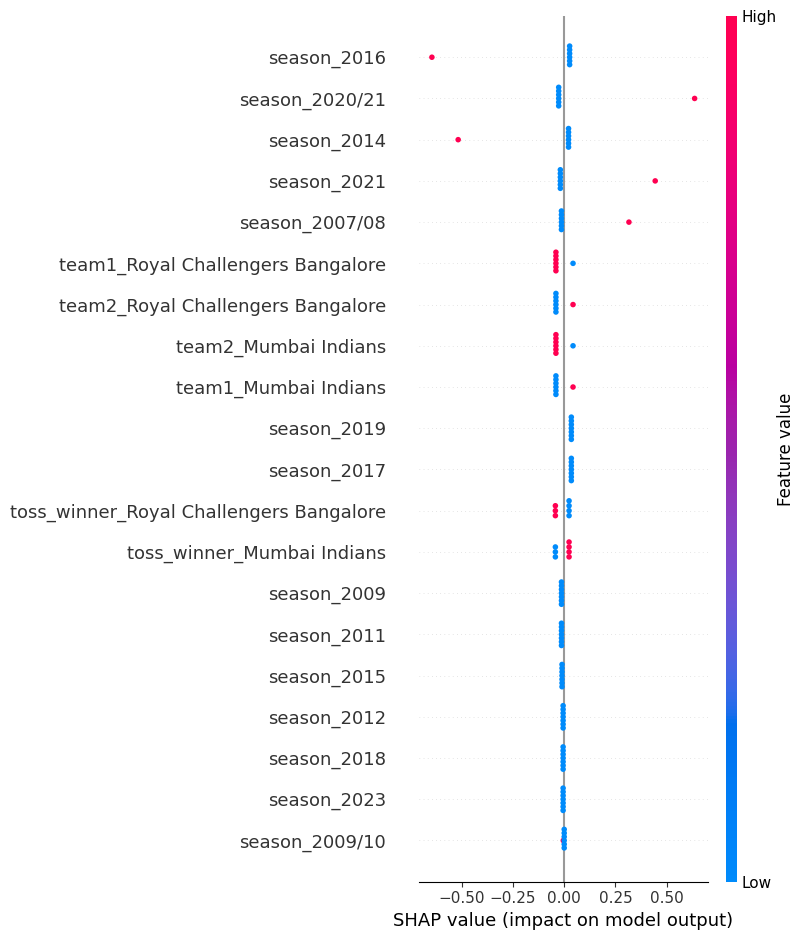

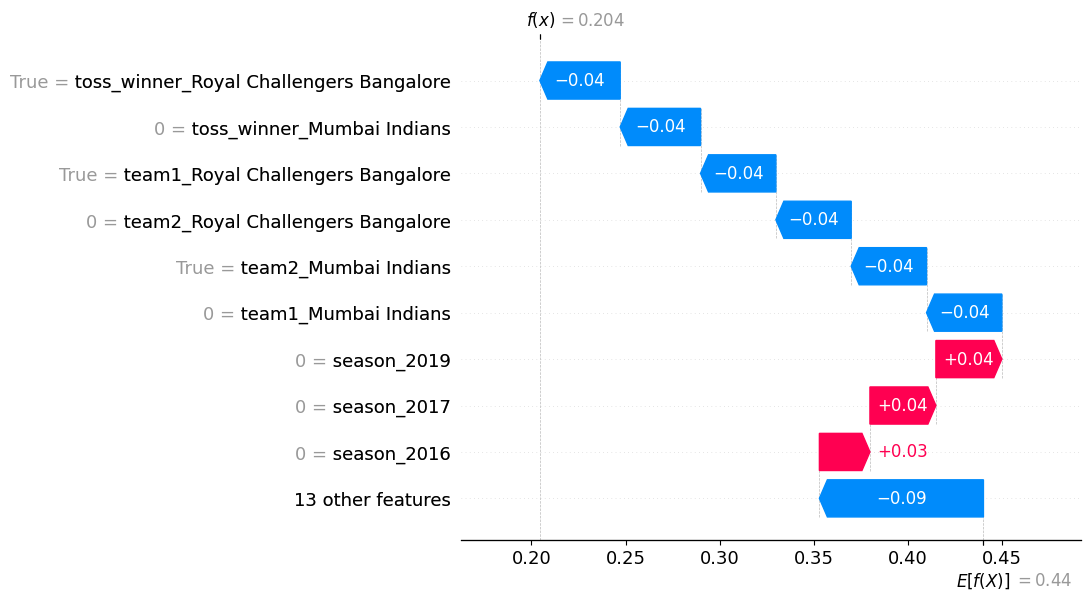

In [86]:
features = ['season','team1','team2','toss_winner']

x = df[features]

y = df['winner'].astype(str)

x = pd.get_dummies(x)


le = LabelEncoder()
y = le.fit_transform(y)



X_train, X_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 100)


model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


y_pred = y_pred.round()

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)




new_match = pd.DataFrame({

    'season': [2026],

    'team1': ['Royal Challengers Bangalore'],

    'team2': ['Mumbai Indians'],

    'toss_winner': ['Royal Challengers Bangalore']

})


new_match = pd.get_dummies(new_match)

new_match = new_match.reindex(columns = x.columns, fill_value = 0)


prediction = model.predict(new_match)

prediction = round(prediction[0])


if prediction == 1:

    print("\nPredicted Winner : Royal Challengers Bangalore\n")

else:

    print("\nPredicted Winner : Mumbai Indians\n")


# SHAP Explaination

explainer = shap.Explainer(model, X_train)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


single_shap = explainer(new_match)

shap.plots.waterfall(single_shap[0])
